# Clustering avec K-Means sur le Dataset CreditDataSet

Ce notebook présente une analyse de clustering utilisant l'algorithme K-Means sur le dataset CreditDataSet qui contient des informations sur les détenteurs de cartes de crédit.

In [3]:
# Importation des bibliothèques nécessaires
!pip install kneed
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from kneed import KneeLocator
import warnings
warnings.filterwarnings('ignore')

## 1. Chargement et exploration des données

## Présentation du jeu de données

Ce jeu de données provient de **Kaggle** et contient des informations détaillées sur le comportement d’utilisation de cartes de crédit par des clients sur une période de **6 mois**.

Chaque ligne correspond à **un client**, et chaque variable décrit un aspect de son comportement financier : dépenses, paiements, fréquence d’utilisation, avances de trésorerie, limite de crédit, etc.



## Objectif du jeu de données

L’objectif principal de ce dataset est de permettre :
- la **segmentation des clients** selon leurs comportements financiers,
- l’identification de **profils d’usage homogènes**,
- une meilleure compréhension des comportements clients dans un contexte bancaire ou financier.

Ce type d’analyse est couramment utilisé en :
- marketing bancaire,
- gestion de la relation client,
- analyse du risque,
- stratégie commerciale.

## Structure générale

- **Unité statistique** : client  
- **Nombre de lignes** : plusieurs milliers de clients  
- **Nombre de variables** : uniquement des variables numériques  
- **Période d’observation** : 6 mois  
- **Type de données** : données comportementales agrégées  



## Description détaillée des variables

### Identification
- `CUST_ID` : identifiant unique du client



### Comportement de solde
- `BALANCE` : solde moyen du compte sur la période  
- `BALANCE_FREQUENCY` : fréquence de mise à jour du solde (proche de 1 = mise à jour régulière)



### Comportement d’achats
- `PURCHASES` : montant total des achats effectués  
- `ONEOFF_PURCHASES` : montant des achats ponctuels  
- `INSTALLMENTS_PURCHASES` : montant des achats en plusieurs fois  
- `PURCHASES_FREQUENCY` : fréquence globale des achats  
- `ONEOFF_PURCHASES_FREQUENCY` : fréquence des achats ponctuels  
- `PURCHASES_INSTALLMENTS_FREQUENCY` : fréquence des achats en plusieurs fois  
- `PURCHASES_TRX` : nombre total de transactions d’achats



### Avances de trésorerie (cash advance)
- `CASH_ADVANCE` : montant total des avances de trésorerie  
- `CASH_ADVANCE_FREQUENCY` : fréquence d’utilisation du cash advance  
- `CASH_ADVANCE_TRX` : nombre de transactions de cash advance  



### Paiements
- `PAYMENTS` : montant total des paiements effectués par le client  
- `MINIMUM_PAYMENTS` : montant total des paiements minimums  
- `PRC_FULL_PAYMENT` : proportion de mois où le client a payé la totalité de son solde



### Limite et ancienneté
- `CREDIT_LIMIT` : limite de crédit accordée au client  
- `TENURE` : ancienneté du client (en mois)



## Problématique data science associée

> **Comment segmenter les clients d’une carte bancaire en profils homogènes à partir de leurs comportements financiers ?**

Cette problématique sera abordée à travers :
- une **Analyse en Composantes Principales (ACP)** pour comprendre la structure des données,
- plusieurs algorithmes de **clustering** (K-means, CAH, DBSCAN),
- une comparaison des méthodes selon des critères statistiques et métier.



## Intérêt du dataset pour le clustering

Ce jeu de données est particulièrement pertinent pour la segmentation car :
- il ne contient **aucune variable cible**,
- il présente une **forte diversité de comportements clients**,
- les variables sont toutes **numériques et continues**,
- les cas d’usage sont **réalistes et proches de situations professionnelles**.



## Exemples de segments attendus

À l’issue de l’analyse, on peut typiquement identifier :
- des clients à forte dépense et paiement intégral,
- des clients peu actifs,
- des clients à forte utilisation du cash advance,
- des clients à limite élevée mais faible utilisation,
- des profils à risque potentiel.



In [4]:
# Chargement du dataset CreditDataSet
df = pd.read_csv('CreditDataSet.csv')
print(f"Forme du dataset: {df.shape}")
df.head()

Forme du dataset: (8950, 18)


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [5]:
# Informations sur le dataset
print("Informations sur les colonnes:")
print(df.info())
print("\nStatistiques descriptives:")
df.describe()

Informations sur les colonnes:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


In [6]:
# Vérification des valeurs manquantes
print("Valeurs manquantes par colonne:")
print(df.isnull().sum())
print(f"\nTotal de valeurs manquantes: {df.isnull().sum().sum()}")

Valeurs manquantes par colonne:
CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

Total de valeurs manquantes: 314


## 2. Préparation des données

In [7]:
# Suppression de la colonne CUST_ID (identifiant unique, non utile pour le clustering)
df_model = df.drop('CUST_ID', axis=1).copy()

# Gestion des valeurs manquantes dans MINIMUM_PAYMENTS
# Si PAYMENTS = 0, alors MINIMUM_PAYMENTS = 0
payments_mean = np.mean(df_model['PAYMENTS'])

for idx, row in df_model.iterrows():
    if pd.isna(row['MINIMUM_PAYMENTS']):
        if row['PAYMENTS'] == 0:
            df_model.loc[idx, 'MINIMUM_PAYMENTS'] = 0
        elif 0 < row['PAYMENTS'] < payments_mean:
            df_model.loc[idx, 'MINIMUM_PAYMENTS'] = row['PAYMENTS']
        else:
            df_model.loc[idx, 'MINIMUM_PAYMENTS'] = payments_mean

# Suppression des lignes avec des valeurs manquantes restantes
df_model = df_model.dropna().reset_index(drop=True)
print(f"Forme du dataset après nettoyage: {df_model.shape}")
print(f"Valeurs manquantes restantes: {df_model.isnull().sum().sum()}")

Forme du dataset après nettoyage: (8949, 17)
Valeurs manquantes restantes: 0


In [8]:
# Normalisation des données avec StandardScaler
scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_model), 
    columns=df_model.columns
)
print("Données normalisées:")
df_scaled.head()

Données normalisées:


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-0.732054,-0.249881,-0.424934,-0.356957,-0.349114,-0.466805,-0.806649,-0.678716,-0.707409,-0.675294,-0.476083,-0.511381,-0.960380,-0.529026,-0.299303,-0.525588,0.360541
1,0.786858,0.134049,-0.469584,-0.356957,-0.454607,2.605438,-1.221928,-0.678716,-0.917090,0.573949,0.110032,-0.591841,0.688601,0.818546,0.100137,0.234159,0.360541
2,0.447041,0.517980,-0.107716,0.108843,-0.454607,-0.466805,1.269742,2.673295,-0.917090,-0.675294,-0.476083,-0.109082,0.826016,-0.383857,-0.090437,-0.525588,0.360541
3,0.049015,-1.017743,0.231995,0.546123,-0.454607,-0.368678,-1.014290,-0.399383,-0.917090,-0.258882,-0.329554,-0.551611,0.826016,-0.598733,-0.359042,-0.525588,0.360541
4,-0.358849,0.517980,-0.462095,-0.347317,-0.454607,-0.466805,-1.014290,-0.399383,-0.917090,-0.675294,-0.476083,-0.551611,-0.905414,-0.364421,-0.254222,-0.525588,0.360541


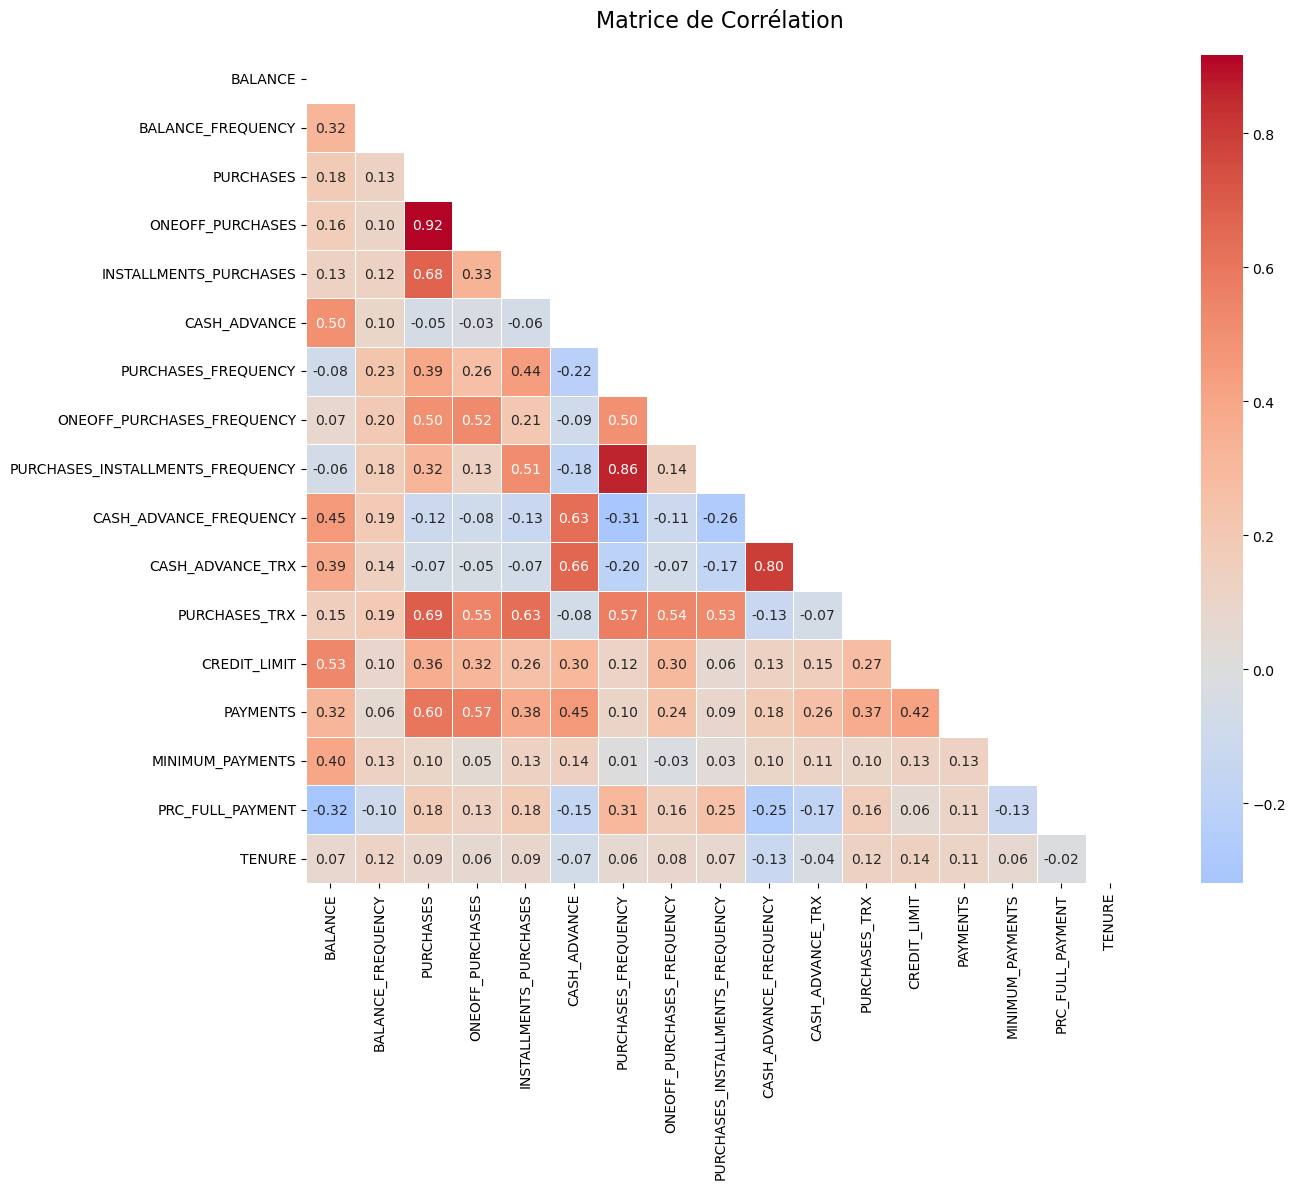

In [9]:
# Matrice de corrélation
corr = df_model.corr()

# Visualisation de la matrice de corrélation
plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, mask=mask, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, fmt='.2f')
plt.title('Matrice de Corrélation', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

## 3. Analyse en Composantes Principales (ACP)

### 3.1 Application de l'ACP

L'Analyse en Composantes Principales (ACP) permet de réduire la dimensionnalité des données tout en conservant le maximum d'information. Elle transforme les variables corrélées en nouvelles variables non corrélées appelées composantes principales.

In [10]:
# Application de l'ACP sur les données normalisées
pca = PCA()
pca.fit(df_scaled)

# Transformation des données en composantes principales
df_pca = pca.transform(df_scaled)

# Création d'un DataFrame avec les composantes principales
df_pca_df = pd.DataFrame(
    data=df_pca,
    columns=[f'PC{i+1}' for i in range(df_pca.shape[1])]
)

print(f"Forme des données après ACP: {df_pca_df.shape}")
print(f"\nPremières composantes principales:")
df_pca_df.head()

Forme des données après ACP: (8949, 17)

Premières composantes principales:


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17
0,-1.684217,-1.071045,-0.474410,0.682919,-0.048638,-0.077779,-0.818837,-0.015483,0.119492,0.079200,-0.236182,0.052491,0.080985,0.188662,-0.149023,0.048194,0.000160
1,-1.133411,2.509873,-0.602310,-0.105362,-0.684536,1.086736,0.385862,0.183247,0.672248,0.779401,-0.870122,0.611170,0.029497,0.728954,0.535258,-0.082949,-0.000003
2,0.968896,-0.383690,-0.091691,1.240570,2.164587,0.364743,1.532230,-0.230609,-0.869302,0.000495,-0.762431,-0.683413,-0.696713,-0.043408,-0.221519,0.511296,-0.000023
3,-0.897116,-0.017686,-1.531308,1.024020,-0.176336,0.202821,0.211663,-0.766442,-0.020399,-0.392096,0.749263,-0.099958,0.109183,0.412427,0.084562,-0.014475,0.000013
4,-1.600453,-0.682446,-0.346283,1.017945,0.447202,-0.080481,-0.694071,0.252568,0.577184,0.123650,-0.455172,0.109321,0.037134,0.041627,-0.290849,-0.070563,0.000081


### 3.2 Variance expliquée et Scree Plot

Variance expliquée par composante principale:
  Composante  Variance expliquée (%)  Variance cumulée (%)
0        PC1                   27.30                 27.30
1        PC2                   20.32                 47.61
2        PC3                    8.82                 56.43
3        PC4                    7.48                 63.91
4        PC5                    6.22                 70.13
5        PC6                    5.73                 75.86
6        PC7                    4.88                 80.75
7        PC8                    4.31                 85.06
8        PC9                    3.79                 88.85
9       PC10                    3.08                 91.93


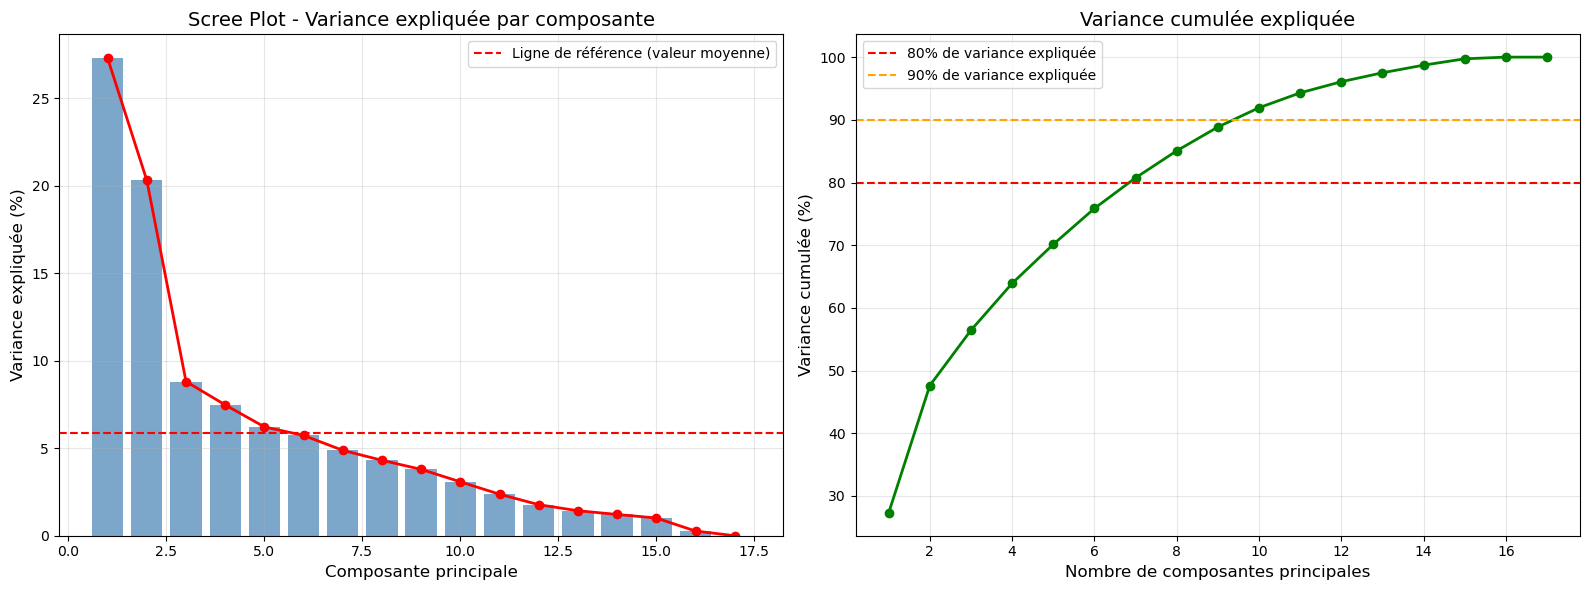


Nombre de composantes pour expliquer:
  - 80% de la variance: 7
  - 90% de la variance: 10


In [11]:
# Calcul de la variance expliquée par chaque composante
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

# Création d'un tableau récapitulatif
variance_df = pd.DataFrame({
    'Composante': [f'PC{i+1}' for i in range(len(explained_variance_ratio))],
    'Variance expliquée (%)': explained_variance_ratio * 100,
    'Variance cumulée (%)': cumulative_variance * 100
})

print("Variance expliquée par composante principale:")
print(variance_df.round(2).head(10))

# Scree plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Graphique de la variance expliquée individuelle
axes[0].bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio * 100, 
           alpha=0.7, color='steelblue')
axes[0].plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio * 100, 
            'ro-', linewidth=2, markersize=6)
axes[0].axhline(y=100/len(explained_variance_ratio), color='r', linestyle='--', 
                label='Ligne de référence (valeur moyenne)')
axes[0].set_xlabel('Composante principale', fontsize=12)
axes[0].set_ylabel('Variance expliquée (%)', fontsize=12)
axes[0].set_title('Scree Plot - Variance expliquée par composante', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Graphique de la variance cumulée
axes[1].plot(range(1, len(cumulative_variance) + 1), cumulative_variance * 100, 
            'go-', linewidth=2, markersize=6)
axes[1].axhline(y=80, color='r', linestyle='--', label='80% de variance expliquée')
axes[1].axhline(y=90, color='orange', linestyle='--', label='90% de variance expliquée')
axes[1].set_xlabel('Nombre de composantes principales', fontsize=12)
axes[1].set_ylabel('Variance cumulée (%)', fontsize=12)
axes[1].set_title('Variance cumulée expliquée', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Trouver le nombre de composantes pour expliquer 80% et 90% de la variance
n_components_80 = np.where(cumulative_variance >= 0.80)[0][0] + 1
n_components_90 = np.where(cumulative_variance >= 0.90)[0][0] + 1

print(f"\nNombre de composantes pour expliquer:")
print(f"  - 80% de la variance: {n_components_80}")
print(f"  - 90% de la variance: {n_components_90}")

### Cercle de corrélation

In [13]:
import numpy as np
import pandas as pd

# Nombre d'axes
n_components = pca.n_components_

# Corrélations variables / axes (loadings)
# shape = (n_features, n_components)
loadings = pca.components_.T

# Cos² des variables sur tous les axes
cos2_vars = pd.DataFrame(
    data=loadings**2,
    index=df_model.columns,
    columns=[f"cos2_PC{k+1}" for k in range(n_components)]
)

# Cos² total (qualité de représentation globale)
cos2_vars["cos2_total"] = cos2_vars.sum(axis=1)

print("Cos² des variables sur tous les axes factoriels :")
print(cos2_vars.round(4))


Cos² des variables sur tous les axes factoriels :
                                  cos2_PC1  cos2_PC2  cos2_PC3  cos2_PC4  \
BALANCE                             0.0104    0.1630    0.0261    0.0776   
BALANCE_FREQUENCY                   0.0145    0.0173    0.1791    0.0247   
PURCHASES                           0.1694    0.0016    0.0663    0.0017   
ONEOFF_PURCHASES                    0.1199    0.0038    0.1528    0.0072   
INSTALLMENTS_PURCHASES              0.1134    0.0004    0.0119    0.0035   
CASH_ADVANCE                        0.0005    0.1927    0.0005    0.0659   
PURCHASES_FREQUENCY                 0.1031    0.0366    0.1377    0.0380   
ONEOFF_PURCHASES_FREQUENCY          0.0867    0.0004    0.0134    0.0012   
PURCHASES_INSTALLMENTS_FREQUENCY    0.0753    0.0320    0.2203    0.0510   
CASH_ADVANCE_FREQUENCY              0.0078    0.1885    0.0109    0.0700   
CASH_ADVANCE_TRX                    0.0023    0.1761    0.0121    0.1078   
PURCHASES_TRX                       0.

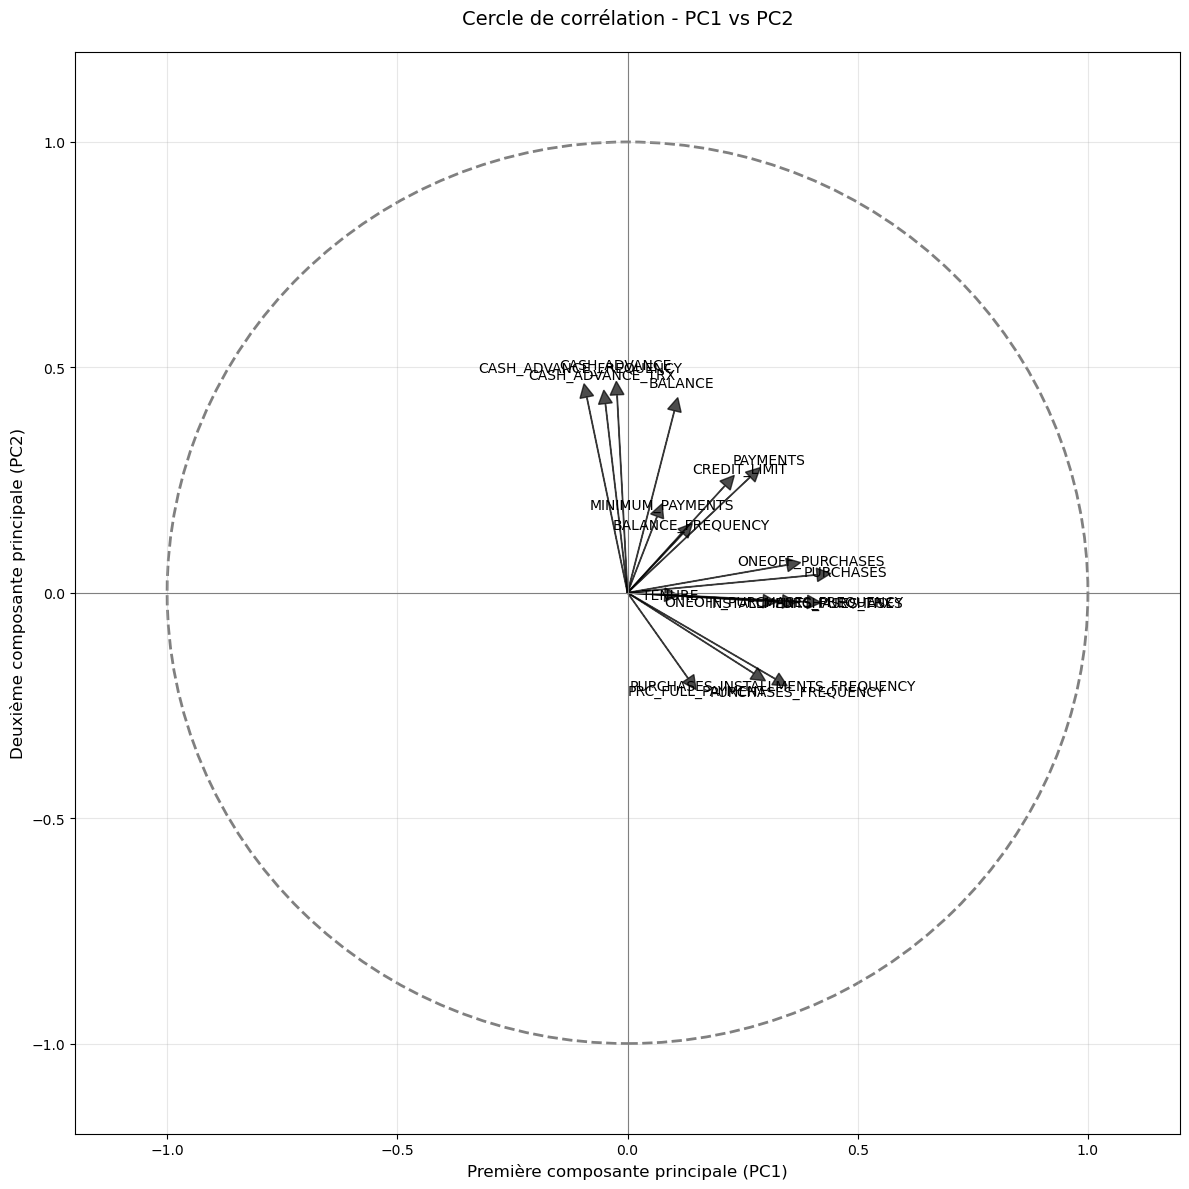

Contributions des variables aux deux premières composantes principales:
                                     PC1     PC2
BALANCE                           0.1019  0.4038
BALANCE_FREQUENCY                 0.1205  0.1315
PURCHASES                         0.4116  0.0398
ONEOFF_PURCHASES                  0.3463  0.0617
INSTALLMENTS_PURCHASES            0.3368 -0.0193
CASH_ADVANCE                     -0.0227  0.4390
PURCHASES_FREQUENCY               0.3212 -0.1913
ONEOFF_PURCHASES_FREQUENCY        0.2944 -0.0187
PURCHASES_INSTALLMENTS_FREQUENCY  0.2744 -0.1790
CASH_ADVANCE_FREQUENCY           -0.0885  0.4341
CASH_ADVANCE_TRX                 -0.0480  0.4196
PURCHASES_TRX                     0.3906 -0.0204
CREDIT_LIMIT                      0.2120  0.2379
PAYMENTS                          0.2666  0.2567
MINIMUM_PAYMENTS                  0.0643  0.1694
PRC_FULL_PAYMENT                  0.1317 -0.1901
TENURE                            0.0809 -0.0043


In [12]:
# Cercle de corrélation pour les deux premières composantes principales
# Les coefficients de corrélation entre les variables originales et les composantes principales
coeff = np.transpose(pca.components_[0:2, :])
n = coeff.shape[0]

# Création du cercle de corrélation
plt.figure(figsize=(12, 12))

# Tracer les vecteurs des variables
for i in range(n):
    plt.arrow(0, 0, coeff[i, 0], coeff[i, 1], 
             color='k', alpha=0.7, head_width=0.03, head_length=0.03)
    plt.text(coeff[i, 0] * 1.15, coeff[i, 1] * 1.15, 
            df_model.columns[i], color='k', ha='center', va='center', fontsize=10)

# Tracer le cercle unitaire
circle = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--', linewidth=2)
plt.gca().add_artist(circle)

# Ajuster les limites et les axes
plt.xlim(-1.2, 1.2)
plt.ylim(-1.2, 1.2)
plt.axhline(0, color='gray', linewidth=0.8, linestyle='-')
plt.axvline(0, color='gray', linewidth=0.8, linestyle='-')
plt.xlabel('Première composante principale (PC1)', fontsize=12)
plt.ylabel('Deuxième composante principale (PC2)', fontsize=12)
plt.title('Cercle de corrélation - PC1 vs PC2', fontsize=14, pad=20)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Afficher les contributions des variables aux composantes principales
print("Contributions des variables aux deux premières composantes principales:")
contributions = pd.DataFrame(
    data=coeff,
    index=df_model.columns,
    columns=['PC1', 'PC2']
)
print(contributions.round(4))

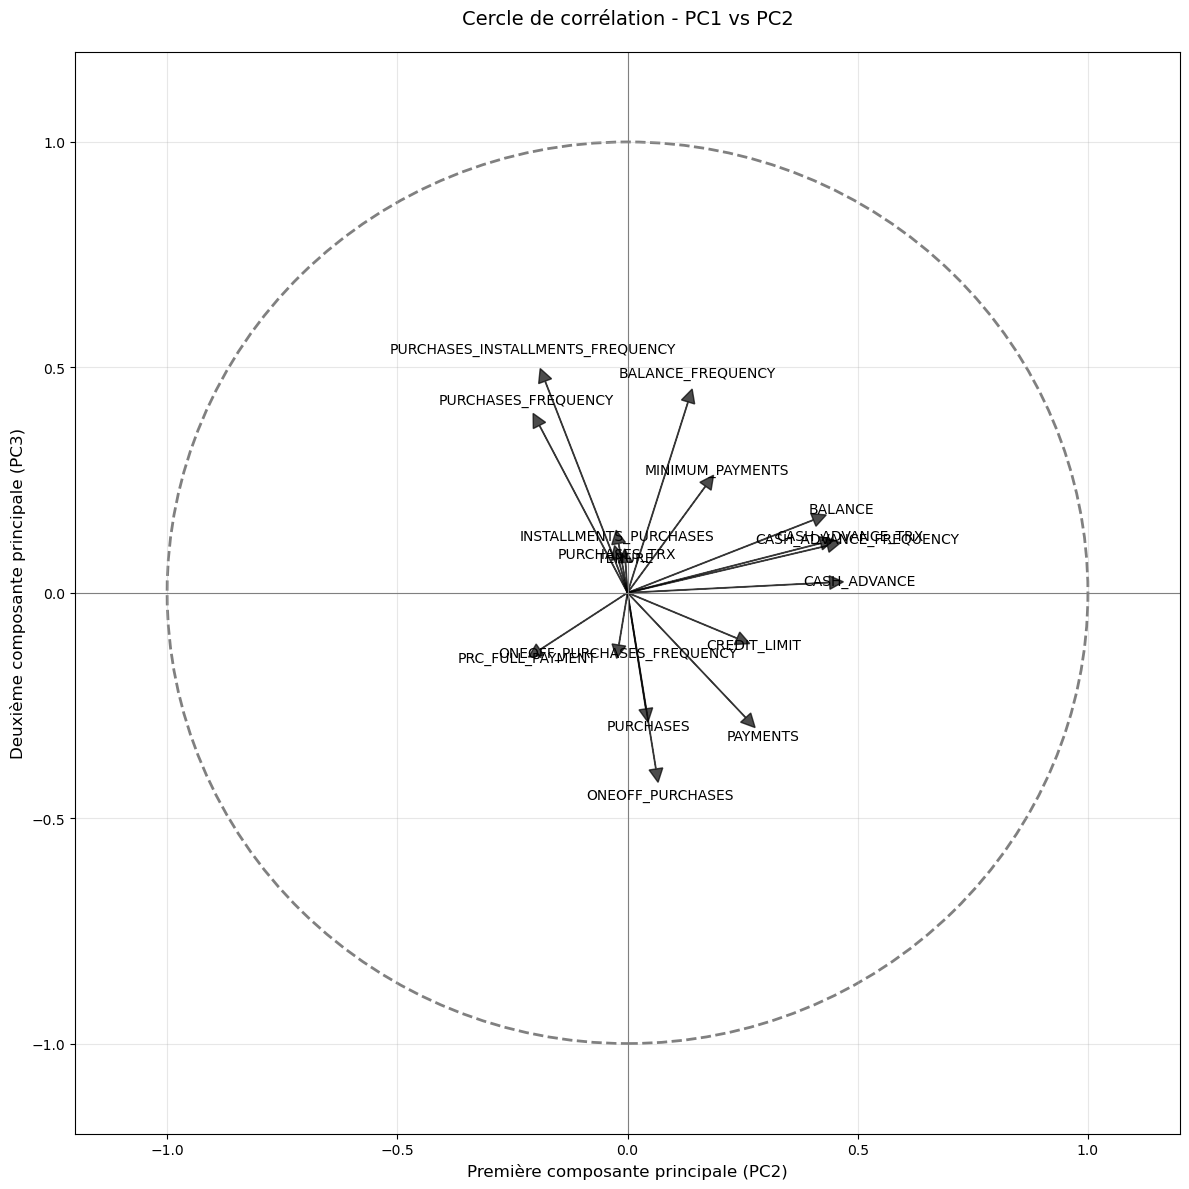

Contributions des variables aux deux premières composantes principales:
                                     PC1     PC2
BALANCE                           0.4038  0.1615
BALANCE_FREQUENCY                 0.1315  0.4232
PURCHASES                         0.0398 -0.2575
ONEOFF_PURCHASES                  0.0617 -0.3908
INSTALLMENTS_PURCHASES           -0.0193  0.1092
CASH_ADVANCE                      0.4390  0.0227
PURCHASES_FREQUENCY              -0.1913  0.3711
ONEOFF_PURCHASES_FREQUENCY       -0.0187 -0.1159
PURCHASES_INSTALLMENTS_FREQUENCY -0.1790  0.4693
CASH_ADVANCE_FREQUENCY            0.4341  0.1044
CASH_ADVANCE_TRX                  0.4196  0.1098
PURCHASES_TRX                    -0.0204  0.0757
CREDIT_LIMIT                      0.2379 -0.1011
PAYMENTS                          0.2567 -0.2770
MINIMUM_PAYMENTS                  0.1694  0.2363
PRC_FULL_PAYMENT                 -0.1901 -0.1263
TENURE                           -0.0043  0.0673


In [14]:
# Cercle de corrélation pour les deux premières composantes principales
# Les coefficients de corrélation entre les variables originales et les composantes principales
coeff = np.transpose(pca.components_[1:3, :])
n = coeff.shape[0]

# Création du cercle de corrélation
plt.figure(figsize=(12, 12))

# Tracer les vecteurs des variables
for i in range(n):
    plt.arrow(0, 0, coeff[i, 0], coeff[i, 1], 
             color='k', alpha=0.7, head_width=0.03, head_length=0.03)
    plt.text(coeff[i, 0] * 1.15, coeff[i, 1] * 1.15, 
            df_model.columns[i], color='k', ha='center', va='center', fontsize=10)

# Tracer le cercle unitaire
circle = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--', linewidth=2)
plt.gca().add_artist(circle)

# Ajuster les limites et les axes
plt.xlim(-1.2, 1.2)
plt.ylim(-1.2, 1.2)
plt.axhline(0, color='gray', linewidth=0.8, linestyle='-')
plt.axvline(0, color='gray', linewidth=0.8, linestyle='-')
plt.xlabel('Première composante principale (PC2)', fontsize=12)
plt.ylabel('Deuxième composante principale (PC3)', fontsize=12)
plt.title('Cercle de corrélation - PC2 vs PC3', fontsize=14, pad=20)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Afficher les contributions des variables aux composantes principales
print("Contributions des variables aux deux premières composantes principales:")
contributions = pd.DataFrame(
    data=coeff,
    index=df_model.columns,
    columns=['PC2', 'PC3']
)
print(contributions.round(4))

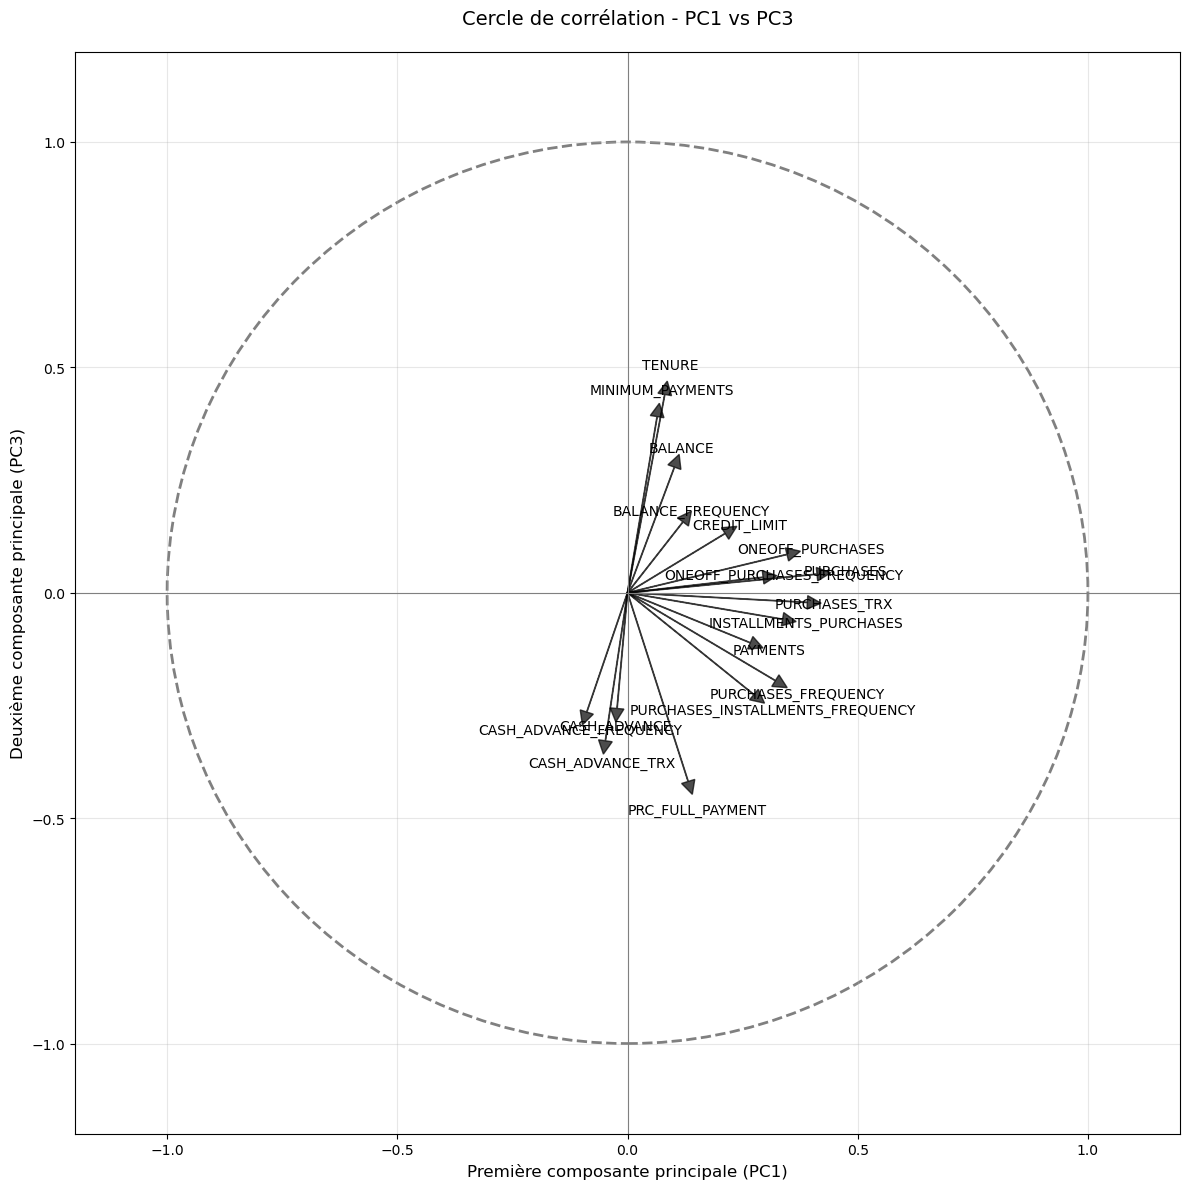

Contributions des variables aux deux premières composantes principales:
                                     PC1     PC3
BALANCE                           0.1019  0.2786
BALANCE_FREQUENCY                 0.1205  0.1571
PURCHASES                         0.4116  0.0412
ONEOFF_PURCHASES                  0.3463  0.0850
INSTALLMENTS_PURCHASES            0.3368 -0.0587
CASH_ADVANCE                     -0.0227 -0.2567
PURCHASES_FREQUENCY               0.3212 -0.1950
ONEOFF_PURCHASES_FREQUENCY        0.2944  0.0344
PURCHASES_INSTALLMENTS_FREQUENCY  0.2744 -0.2259
CASH_ADVANCE_FREQUENCY           -0.0885 -0.2646
CASH_ADVANCE_TRX                 -0.0480 -0.3283
PURCHASES_TRX                     0.3906 -0.0214
CREDIT_LIMIT                      0.2120  0.1314
PAYMENTS                          0.2666 -0.1110
MINIMUM_PAYMENTS                  0.0643  0.3907
PRC_FULL_PAYMENT                  0.1317 -0.4186
TENURE                            0.0809  0.4399


In [15]:
# Cercle de corrélation pour les deux premières composantes principales
# Les coefficients de corrélation entre les variables originales et les composantes principales
coeff = np.transpose(pca.components_[[0,3], :])
n = coeff.shape[0]

# Création du cercle de corrélation
plt.figure(figsize=(12, 12))

# Tracer les vecteurs des variables
for i in range(n):
    plt.arrow(0, 0, coeff[i, 0], coeff[i, 1], 
             color='k', alpha=0.7, head_width=0.03, head_length=0.03)
    plt.text(coeff[i, 0] * 1.15, coeff[i, 1] * 1.15, 
            df_model.columns[i], color='k', ha='center', va='center', fontsize=10)

# Tracer le cercle unitaire
circle = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--', linewidth=2)
plt.gca().add_artist(circle)

# Ajuster les limites et les axes
plt.xlim(-1.2, 1.2)
plt.ylim(-1.2, 1.2)
plt.axhline(0, color='gray', linewidth=0.8, linestyle='-')
plt.axvline(0, color='gray', linewidth=0.8, linestyle='-')
plt.xlabel('Première composante principale (PC1)', fontsize=12)
plt.ylabel('Deuxième composante principale (PC3)', fontsize=12)
plt.title('Cercle de corrélation - PC1 vs PC3', fontsize=14, pad=20)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Afficher les contributions des variables aux composantes principales
print("Contributions des variables aux deux premières composantes principales:")
contributions = pd.DataFrame(
    data=coeff,
    index=df_model.columns,
    columns=['PC1', 'PC3']
)
print(contributions.round(4))

### 3.4 Représentation des individus sur le plan factoriel

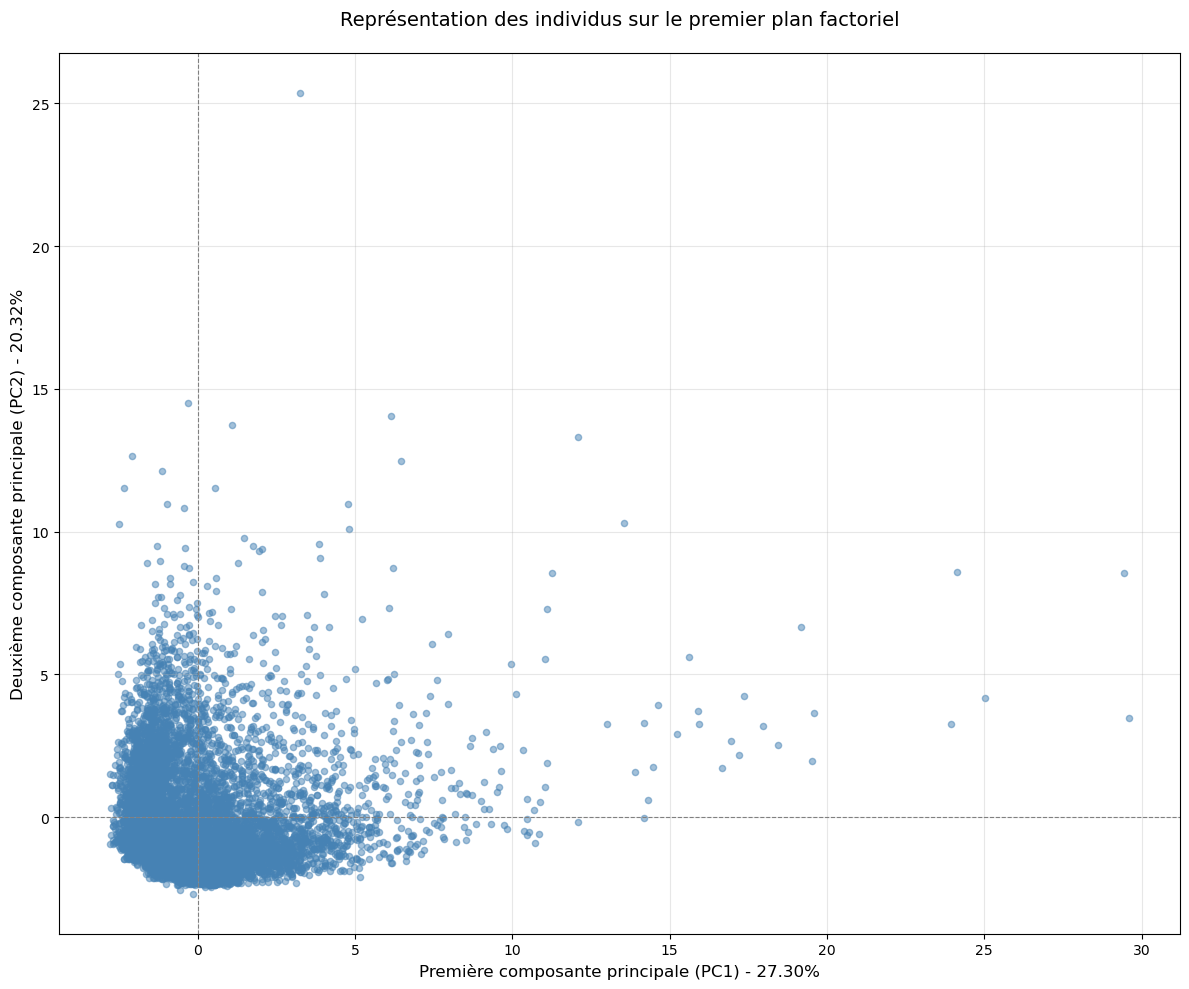

In [16]:
# Représentation des individus sur le premier plan factoriel (PC1 vs PC2)
plt.figure(figsize=(12, 10))
plt.scatter(df_pca[:, 0], df_pca[:, 1], alpha=0.5, s=20, c='steelblue')
plt.axhline(0, color='gray', linewidth=0.8, linestyle='--')
plt.axvline(0, color='gray', linewidth=0.8, linestyle='--')
plt.xlabel(f'Première composante principale (PC1) - {explained_variance_ratio[0]*100:.2f}%', fontsize=12)
plt.ylabel(f'Deuxième composante principale (PC2) - {explained_variance_ratio[1]*100:.2f}%', fontsize=12)
plt.title('Représentation des individus sur le premier plan factoriel', fontsize=14, pad=20)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 3.5 Choix du nombre de composantes principales

Nous allons choisir le nombre de composantes principales à utiliser pour le clustering. Plusieurs critères peuvent être utilisés :
- La règle de Kaiser : garder les composantes avec une valeur propre > 1
- La règle du pourcentage de variance expliquée (80% ou 90%)
- La méthode du coude dans le scree plot

In [ ]:
# Valeurs propres (eigenvalues)
eigenvalues = pca.explained_variance_

# Règle de Kaiser : garder les composantes avec valeur propre > 1
n_components_kaiser = np.sum(eigenvalues > 1)

print("Critères pour choisir le nombre de composantes principales:")
print(f"  - Règle de Kaiser (valeur propre > 1): {n_components_kaiser} composantes")
print(f"  - Pour expliquer 80% de variance: {n_components_80} composantes")
print(f"  - Pour expliquer 90% de variance: {n_components_90} composantes")

# Visualisation des valeurs propres
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(eigenvalues) + 1), eigenvalues, alpha=0.7, color='steelblue')
plt.axhline(y=1, color='r', linestyle='--', linewidth=2, label='Règle de Kaiser (valeur propre = 1)')
plt.plot(range(1, len(eigenvalues) + 1), eigenvalues, 'ro-', linewidth=2, markersize=6)
plt.xlabel('Composante principale', fontsize=12)
plt.ylabel('Valeur propre', fontsize=12)
plt.title('Valeurs propres des composantes principales', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Choix du nombre de composantes (on peut utiliser plusieurs critères)
# Ici, nous choisissons un compromis entre les critères
n_components_chosen = min(n_components_80, n_components_kaiser + 2)  # Compromis
n_components_chosen = max(2, min(n_components_chosen, 10))  # Entre 2 et 10

print(f"\nNombre de composantes choisies pour le clustering: {n_components_chosen}")
print(f"Variance expliquée par ces {n_components_chosen} composantes: {cumulative_variance[n_components_chosen-1]*100:.2f}%")

In [ ]:
# Application de l'ACP avec le nombre de composantes choisies
pca_final = PCA(n_components=n_components_chosen)
df_pca_final = pca_final.fit_transform(df_scaled)

# Création d'un DataFrame avec les composantes principales sélectionnées
df_pca_final_df = pd.DataFrame(
    data=df_pca_final,
    columns=[f'PC{i+1}' for i in range(n_components_chosen)]
)

print(f"Forme des données après ACP avec {n_components_chosen} composantes: {df_pca_final_df.shape}")
print(f"Variance expliquée: {pca_final.explained_variance_ratio_.sum()*100:.2f}%")
print(f"\nPremières lignes des composantes principales:")
df_pca_final_df.head()

# Nous utiliserons df_pca_final pour le clustering K-Means au lieu de df_scaled

## 4. Détermination du nombre optimal de clusters

In [ ]:
pip install kneed

In [ ]:
# Si besoin : pip install kneed
from kneed import KneeLocator


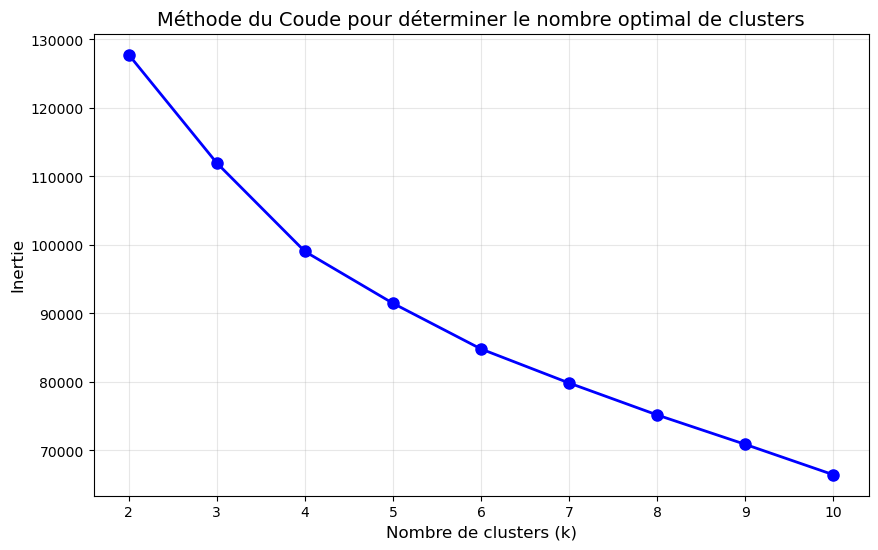

Nombre optimal de clusters (méthode du coude): 4


In [17]:
# Méthode du coude (Elbow Method)
# Calcul de l'inertie pour différents nombres de clusters
inertias = []
K_range = range(2, 11)

kmeans_settings = {"init": "random", "n_init": 10, "max_iter": 300, "random_state": 42}

for k in K_range:
    kmeans = KMeans(n_clusters=k, **kmeans_settings)
    kmeans.fit(df_scaled)
    inertias.append(kmeans.inertia_)

# Visualisation de la méthode du coude
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Nombre de clusters (k)', fontsize=12)
plt.ylabel('Inertie', fontsize=12)
plt.title('Méthode du Coude pour déterminer le nombre optimal de clusters', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

# Trouver le point optimal avec KneeLocator
knee_locator = KneeLocator(K_range, inertias, curve='convex', direction='decreasing')
optimal_k_elbow = knee_locator.elbow
print(f"Nombre optimal de clusters (méthode du coude): {optimal_k_elbow}")

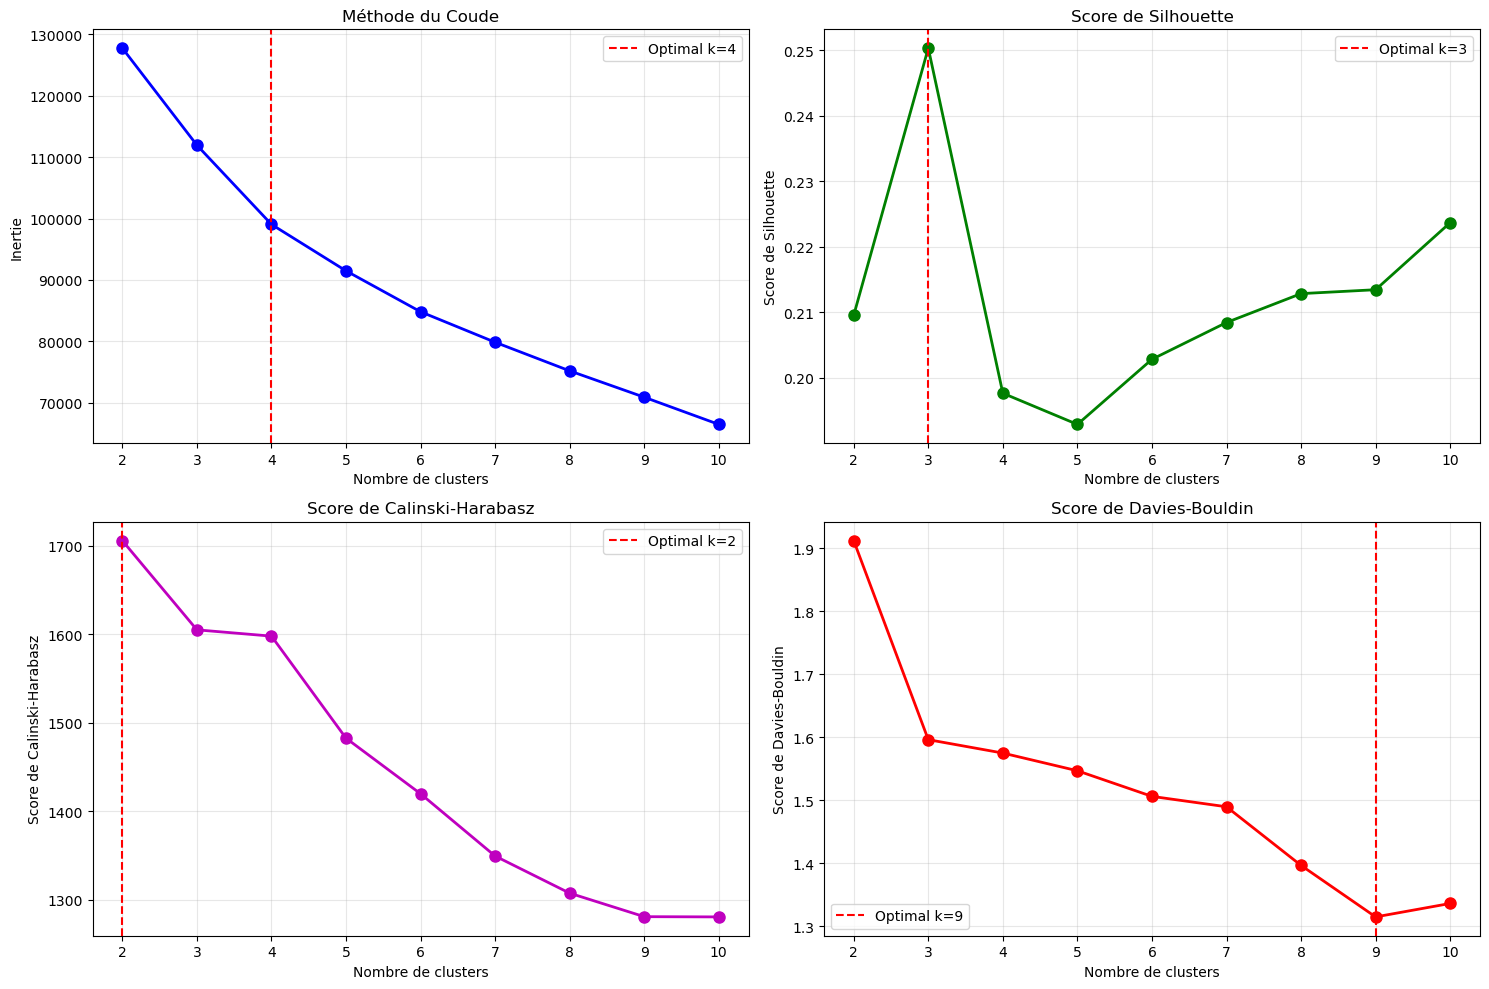


Nombre optimal selon:
  - Méthode du coude: 4
  - Score de Silhouette: 3 (score: 0.2504)
  - Score de Calinski-Harabasz: 2 (score: 1705.8025)
  - Score de Davies-Bouldin: 9 (score: 1.3148)


In [18]:
# Calcul des métriques d'évaluation pour différents nombres de clusters
silhouette_scores = []
calinski_harabasz_scores = []
davies_bouldin_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, **kmeans_settings)
    kmeans.fit(df_scaled)
    labels = kmeans.labels_
    
    silhouette_scores.append(silhouette_score(df_scaled, labels))
    calinski_harabasz_scores.append(calinski_harabasz_score(df_scaled, labels))
    davies_bouldin_scores.append(davies_bouldin_score(df_scaled, labels))

# Visualisation des métriques d'évaluation
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Inertie
axes[0, 0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0, 0].axvline(x=optimal_k_elbow, color='r', linestyle='--', label=f'Optimal k={optimal_k_elbow}')
axes[0, 0].set_xlabel('Nombre de clusters')
axes[0, 0].set_ylabel('Inertie')
axes[0, 0].set_title('Méthode du Coude')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

# Score de Silhouette (plus élevé = mieux)
axes[0, 1].plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
optimal_k_silhouette = K_range[np.argmax(silhouette_scores)]
axes[0, 1].axvline(x=optimal_k_silhouette, color='r', linestyle='--', 
                   label=f'Optimal k={optimal_k_silhouette}')
axes[0, 1].set_xlabel('Nombre de clusters')
axes[0, 1].set_ylabel('Score de Silhouette')
axes[0, 1].set_title('Score de Silhouette')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

# Score de Calinski-Harabasz (plus élevé = mieux)
axes[1, 0].plot(K_range, calinski_harabasz_scores, 'mo-', linewidth=2, markersize=8)
optimal_k_ch = K_range[np.argmax(calinski_harabasz_scores)]
axes[1, 0].axvline(x=optimal_k_ch, color='r', linestyle='--', 
                   label=f'Optimal k={optimal_k_ch}')
axes[1, 0].set_xlabel('Nombre de clusters')
axes[1, 0].set_ylabel('Score de Calinski-Harabasz')
axes[1, 0].set_title('Score de Calinski-Harabasz')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

# Score de Davies-Bouldin (plus bas = mieux)
axes[1, 1].plot(K_range, davies_bouldin_scores, 'ro-', linewidth=2, markersize=8)
optimal_k_db = K_range[np.argmin(davies_bouldin_scores)]
axes[1, 1].axvline(x=optimal_k_db, color='r', linestyle='--', 
                   label=f'Optimal k={optimal_k_db}')
axes[1, 1].set_xlabel('Nombre de clusters')
axes[1, 1].set_ylabel('Score de Davies-Bouldin')
axes[1, 1].set_title('Score de Davies-Bouldin')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print(f"\nNombre optimal selon:")
print(f"  - Méthode du coude: {optimal_k_elbow}")
print(f"  - Score de Silhouette: {optimal_k_silhouette} (score: {max(silhouette_scores):.4f})")
print(f"  - Score de Calinski-Harabasz: {optimal_k_ch} (score: {max(calinski_harabasz_scores):.4f})")
print(f"  - Score de Davies-Bouldin: {optimal_k_db} (score: {min(davies_bouldin_scores):.4f})")

## 5. Application de K-Means avec le nombre optimal de clusters

In [23]:
# Application de K-Means avec le nombre optimal de clusters (choisissons 3 ou 4 selon les métriques)
optimal_k = 3  # Vous pouvez ajuster selon vos besoins

kmeans_final = KMeans(n_clusters=optimal_k, **kmeans_settings)
kmeans_final.fit(df_scaled)

# Obtenir les labels de cluster
labels = kmeans_final.labels_

# Ajouter les labels au DataFrame original
df_model['cluster'] = labels

# Centres des clusters (normalisés)
centroids_scaled = pd.DataFrame(
    data=kmeans_final.cluster_centers_, 
    columns=df_scaled.columns
)

# Centres des clusters (dans l'échelle originale)
centroids_original = pd.DataFrame(
    data=scaler.inverse_transform(kmeans_final.cluster_centers_),
    columns=df_model.columns.drop('cluster')
)

print("Centres des clusters (échelle originale):")
centroids_original



Centres des clusters (échelle originale):


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,799.289199,0.835186,506.129389,253.394730,253.055508,330.377802,0.465461,0.132464,0.345474,0.068148,1.208075,8.662471,3273.598167,909.509644,514.878571,0.155944,11.480549
1,2233.373818,0.981477,4269.155174,2717.493579,1552.147425,461.587792,0.949093,0.667761,0.744787,0.063419,1.538462,56.526316,7734.372470,4155.605895,1247.830477,0.297727,11.923077
2,3981.054714,0.958403,382.065802,248.083296,134.059994,3865.537146,0.231089,0.110838,0.143041,0.447445,12.396617,5.542607,6667.296081,3016.964383,1762.226806,0.033827,11.347744


In [24]:

mapping_table = pd.DataFrame(
    list(variables_fr.items()),
    columns=["Variable (EN)", "Variable (FR)"]
)

mapping_table

,Variable (EN),Variable (FR)
0,BALANCE,Solde moyen de la carte
1,BALANCE_FREQUENCY,Fréquence de mise à jour du solde
2,PURCHASES,Montant total des achats
3,ONEOFF_PURCHASES,Montant des achats en une fois
4,INSTALLMENTS_PURCHASES,Montant des achats en plusieurs fois
5,CASH_ADVANCE,Montant des avances de trésorerie
6,PURCHASES_FREQUENCY,Fréquence des achats
7,ONEOFF_PURCHASES_FREQUENCY,Fréquence des achats en une fois
8,PURCHASES_INSTALLMENTS_FREQUENCY,Fréquence des achats en plusieurs fois
9,CASH_ADVANCE_FREQUENCY,Fréquence des avances de trésorerie


In [22]:
variables_fr = {
    "BALANCE": "Solde moyen de la carte",
    "BALANCE_FREQUENCY": "Fréquence de mise à jour du solde",
    "PURCHASES": "Montant total des achats",
    "ONEOFF_PURCHASES": "Montant des achats en une fois",
    "INSTALLMENTS_PURCHASES": "Montant des achats en plusieurs fois",
    "CASH_ADVANCE": "Montant des avances de trésorerie",
    "PURCHASES_FREQUENCY": "Fréquence des achats",
    "ONEOFF_PURCHASES_FREQUENCY": "Fréquence des achats en une fois",
    "PURCHASES_INSTALLMENTS_FREQUENCY": "Fréquence des achats en plusieurs fois",
    "CASH_ADVANCE_FREQUENCY": "Fréquence des avances de trésorerie",
    "CASH_ADVANCE_TRX": "Nombre d’opérations d’avance de trésorerie",
    "PURCHASES_TRX": "Nombre total d’achats",
    "CREDIT_LIMIT": "Plafond de crédit",
    "PAYMENTS": "Montant total des paiements",
    "MINIMUM_PAYMENTS": "Montant minimum des paiements",
    "PRC_FULL_PAYMENT": "Pourcentage de paiement intégral",
    "TENURE": "Ancienneté du client (en mois)"
}

optimal_k = 3

kmeans_final = KMeans(n_clusters=optimal_k, **kmeans_settings)
kmeans_final.fit(df_scaled)

labels = kmeans_final.labels_
df_model["cluster"] = labels


centroids_original = pd.DataFrame(
    data=scaler.inverse_transform(kmeans_final.cluster_centers_),
    columns=df_model.columns.drop("cluster")
)

# Renommer les colonnes en français
centroids_original_fr = centroids_original.rename(columns=variables_fr)

# Ajouter l’identifiant du cluster
centroids_original_fr["Cluster"] = centroids_original_fr.index

# Réordonner pour lisibilité
centroids_original_fr = centroids_original_fr.set_index("Cluster")

print("Centres des clusters (échelle originale – variables en français) :")
print(centroids_original_fr.round(2))


mapping_table = pd.DataFrame(
    list(variables_fr.items()),
    columns=["Variable (EN)", "Variable (FR)"]
)

mapping_table


Centres des clusters (échelle originale – variables en français) :
         Solde moyen de la carte  Fréquence de mise à jour du solde  \
Cluster                                                               
0                         799.29                               0.84   
1                        2233.37                               0.98   
2                        3981.05                               0.96   

         Montant total des achats  Montant des achats en une fois  \
Cluster                                                             
0                          506.13                          253.39   
1                         4269.16                         2717.49   
2                          382.07                          248.08   

         Montant des achats en plusieurs fois  \
Cluster                                         
0                                      253.06   
1                                     1552.15   
2                                  

,Variable (EN),Variable (FR)
0,BALANCE,Solde moyen de la carte
1,BALANCE_FREQUENCY,Fréquence de mise à jour du solde
2,PURCHASES,Montant total des achats
3,ONEOFF_PURCHASES,Montant des achats en une fois
4,INSTALLMENTS_PURCHASES,Montant des achats en plusieurs fois
5,CASH_ADVANCE,Montant des avances de trésorerie
6,PURCHASES_FREQUENCY,Fréquence des achats
7,ONEOFF_PURCHASES_FREQUENCY,Fréquence des achats en une fois
8,PURCHASES_INSTALLMENTS_FREQUENCY,Fréquence des achats en plusieurs fois
9,CASH_ADVANCE_FREQUENCY,Fréquence des avances de trésorerie


In [20]:
# Statistiques par cluster
print("Répartition des clusters:")
print(df_model['cluster'].value_counts().sort_index())

print("\n\nStatistiques descriptives par cluster:")
cluster_stats = df_model.groupby('cluster').mean()
cluster_stats

Répartition des clusters:
cluster
0    6118
1    1237
2    1594
Name: count, dtype: int64


Statistiques descriptives par cluster:


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
cluster,,,,,,,,,,,,,,,,,
0,799.878382,0.835186,505.615025,253.161504,252.774371,330.841416,0.465148,0.132355,0.345201,0.068243,1.209709,8.655280,3271.555016,909.824303,515.068220,0.155775,11.480549
1,2230.302719,0.981507,4264.856928,2714.253395,1551.088577,460.879510,0.949175,0.667220,0.744997,0.063383,1.536783,56.471302,7735.610348,4150.678057,1246.098480,0.298149,11.923201
2,3983.369449,0.958351,382.498444,248.394567,134.181462,3868.578334,0.231327,0.110977,0.143169,0.447588,12.405270,5.548934,6672.838485,3018.152191,1763.488415,0.033817,11.346926


## 6. Visualisation des résultats

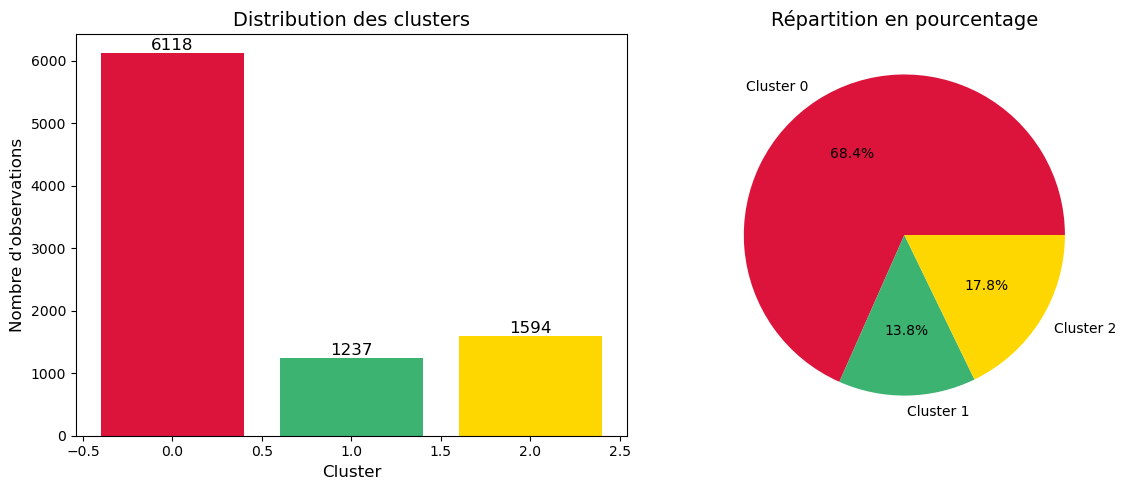

In [21]:
# Distribution des clusters
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
cluster_counts = df_model['cluster'].value_counts().sort_index()
plt.bar(cluster_counts.index, cluster_counts.values, color=['crimson', 'MediumSeaGreen', 'gold'])
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Nombre d\'observations', fontsize=12)
plt.title('Distribution des clusters', fontsize=14)
for i, v in enumerate(cluster_counts.values):
    plt.text(i, v + 50, str(v), ha='center', fontsize=12)

plt.subplot(1, 2, 2)
plt.pie(cluster_counts.values, labels=[f'Cluster {i}' for i in cluster_counts.index], 
        autopct='%1.1f%%', colors=['crimson', 'MediumSeaGreen', 'gold'])
plt.title('Répartition en pourcentage', fontsize=14)

plt.tight_layout()
plt.show()

In [ ]:
# Visualisation des clusters sur plusieurs dimensions
# Sélection de quelques variables importantes pour la visualisation
important_vars = ['BALANCE', 'PURCHASES', 'CREDIT_LIMIT', 'PAYMENTS']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

palette = ['crimson', 'MediumSeaGreen', 'gold']

for idx, var in enumerate(important_vars):
    ax = axes[idx]
    for cluster_id in sorted(df_model['cluster'].unique()):
        cluster_data = df_model[df_model['cluster'] == cluster_id]
        ax.scatter(cluster_data[var], cluster_data['PURCHASES'], 
                  label=f'Cluster {cluster_id}', alpha=0.6, s=50, color=palette[cluster_id])
    ax.set_xlabel(var, fontsize=12)
    ax.set_ylabel('PURCHASES', fontsize=12)
    ax.set_title(f'Clusters selon {var} vs PURCHASES', fontsize=12)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(12, 10))
palette = ['crimson', 'MediumSeaGreen', 'gold']

for cluster_id in sorted(df_model['cluster'].unique()):
    cluster_mask = df_model['cluster'] == cluster_id
    plt.scatter(
        df_pca[cluster_mask, 0], df_pca[cluster_mask, 1],
        label=f'Cluster {cluster_id}', alpha=0.6, s=30, color=palette[cluster_id]
    )

# Centres KMeans projetés dans l'espace PCA
centroids_pca_space = pca.transform(kmeans_final.cluster_centers_)
for i, (x, y) in enumerate(centroids_pca_space[:, :2]):
    plt.scatter(
        x, y, marker='x', s=200, linewidths=3, color='black',
        label=f'Centre Cluster {i}' if i == 0 else ''
    )

plt.axhline(0, color='gray', linewidth=0.8, linestyle='--')
plt.axvline(0, color='gray', linewidth=0.8, linestyle='--')
plt.xlabel(f'PC1 - {explained_variance_ratio[0]*100:.2f}%', fontsize=12)
plt.ylabel(f'PC2 - {explained_variance_ratio[1]*100:.2f}%', fontsize=12)
plt.title('Clusters K-Means sur le premier plan factoriel', fontsize=14, pad=20)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# Boxplots pour comparer les clusters sur différentes variables
num_vars = len(important_vars)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for idx, var in enumerate(important_vars):
    sns.boxplot(data=df_model, x='cluster', y=var, ax=axes[idx], palette=palette)
    axes[idx].set_title(f'Distribution de {var} par cluster', fontsize=12)
    axes[idx].set_xlabel('Cluster', fontsize=11)
    axes[idx].set_ylabel(var, fontsize=11)

plt.tight_layout()
plt.show()

## 7. Métriques d'évaluation finales

In [ ]:
# Calcul des métriques d'évaluation finales
final_silhouette = silhouette_score(df_scaled, labels)
final_calinski = calinski_harabasz_score(df_scaled, labels)
final_davies = davies_bouldin_score(df_scaled, labels)

print("Métriques d'évaluation finales:")
print(f"  - Score de Silhouette: {final_silhouette:.4f}")
print(f"  - Score de Calinski-Harabasz: {final_calinski:.4f}")
print(f"  - Score de Davies-Bouldin: {final_davies:.4f}")
print(f"\nNombre de clusters utilisés: {optimal_k}")
print(f"Nombre total d'observations: {len(df_model)}")